In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   --- ------------------------------------ 3.4/40.2 MB 17.2 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/40.2 MB 18.0 MB/s eta 0:00:02
   ---------- ----------------------------- 10.2/40.2 MB 16.6 MB/s eta 0:00:02
   ------------- -------------------------- 13.1/40.2 MB 15.9 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/40.2 MB 16.2 MB/s eta 0:00:02
   -------------------- ------------------- 20.2/40.2 MB 16.4 MB/s eta 0:00:02
   ----------------------- ---------------- 23.9/40.2 MB 16.5 MB/s eta 0:00:01
   --------------------------- ------------ 27.3/40.2 MB 16.5 MB/s eta 0:00:01
   ------------------------------ --------- 30.9/40.2 MB 16.6 MB/s eta 0:00:01
   ---------------------------------- ----- 34.3/40.2 MB 16.6 MB/s eta 0:00:01
   ------------------------------------- -- 37.7/40.2 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 16.5 M

Found 253 files belonging to 2 classes.
Found 253 files belonging to 2 classes.


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6601 - loss: 0.8029 - val_accuracy: 0.7826 - val_loss: 0.4826
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7945 - loss: 0.5262 - val_accuracy: 0.7984 - val_loss: 0.4674
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7984 - loss: 0.4837 - val_accuracy: 0.8142 - val_loss: 0.4308
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8103 - loss: 0.4523 - val_accuracy: 0.8498 - val_loss: 0.3890
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8221 - loss: 0.3913 - val_accuracy: 0.9091 - val_loss: 0.3311
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
Tumor Detected


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


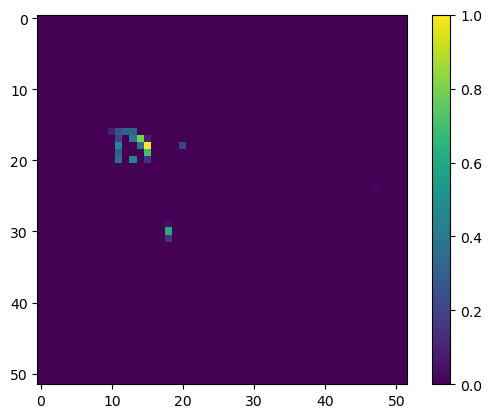

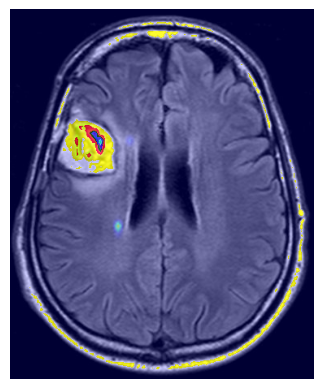

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
img_size = (224,224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/shubh/Downloads/archive (9)/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/shubh/Downloads/archive (9)/brain_tumor_dataset",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds = test_ds.map(lambda x,y:(normalization_layer(x),y))
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5     # CHANGE HERE → agar training slow ho to 5 kar sakte ho
)
img = keras.preprocessing.image.load_img(
    "C:/Users/shubh/Downloads/archive (9)/brain_tumor_dataset/yes/Y7.jpg",   # CHANGE HERE → apni test MRI image ka path
    target_size=(224,224)
)

img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)/255

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")
# force model to build
_ = model(img_array)
# get last convolution layer
last_conv_layer = model.layers[4]

# create grad model
grad_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.layers[-1].output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

# gradients
grads = tape.gradient(loss, conv_outputs)

# average gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# weight feature maps
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# normalize
heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

# display
plt.imshow(heatmap)
plt.colorbar()
plt.show()
import cv2
import numpy as np
import matplotlib.pyplot as plt

# CHANGE HERE → same test image path jo prediction me use ki thi
img_path = "C:/Users/shubh/Downloads/archive (9)/brain_tumor_dataset/yes/Y7.jpg"

img = cv2.imread(img_path)

# resize heatmap
heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))

# convert to 0-255
heatmap = np.uint8(255 * heatmap)

# apply color map
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# overlay heatmap
superimposed = heatmap * 0.4 + img

# display
plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()